# Feature Importance (3-hour collision risk, y_class 0/1/2)

This notebook computes **feature importance** for your current champion model(s) for:

- **y_class = 0** → 0 collisions in next 3 hours  
- **y_class = 1** → 1 collision in next 3 hours  
- **y_class = 2** → 2+ collisions in next 3 hours  

We compute importance using **validation data only** (no test leakage) using:

1) **CatBoost built-in** importance (PredictionValuesChange)  
2) **Permutation importance** on Validation (macro-recall and your 2-threshold decision rule)

Outputs saved to `../models/` for later use in feature selection 

> **Important:** Feature selection decisions must be based on **Train/Val** only. The Test set is used once at the end.


In [6]:
# ============================================================
# 0) Imports + paths
# ============================================================
from __future__ import annotations

from pathlib import Path
import json
import numpy as np
import pandas as pd

from sklearn.metrics import recall_score, precision_score
import matplotlib.pyplot as plt

# Project paths (assumes this notebook lives in notebooks/)
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Dataset (update if your filename differs)
SUPERVISED_PATH = DATA_DIR / "supervised_hood_3h_multiclass.csv"

# Saved models (from your training notebooks)
CB_MODEL_PATH = MODEL_DIR / "best_ml_catboost.cbm"
LGBM_MODEL_PATH = MODEL_DIR / "best_ml_lightgbm.joblib"

# Optional saved thresholds (two-threshold JSON)
CB_THR_PATH = MODEL_DIR / "best_ml_catboost_thresholds.json"
LGBM_THR_PATH = MODEL_DIR / "best_ml_lightgbm_thresholds.json"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Dataset:", SUPERVISED_PATH)
print("CatBoost model:", CB_MODEL_PATH, "exists:", CB_MODEL_PATH.exists())
print("LightGBM pipeline:", LGBM_MODEL_PATH, "exists:", LGBM_MODEL_PATH.exists())


Dataset: ../data/processed/supervised_hood_3h_multiclass.csv
CatBoost model: ../models/best_ml_catboost.cbm exists: True
LightGBM pipeline: ../models/best_ml_lightgbm.joblib exists: True


In [7]:
# ============================================================
# 1) Load dataset + Train/Val/Test split (time-based)
# ============================================================
df = pd.read_csv(SUPERVISED_PATH, low_memory=False)
df["time_3h"] = pd.to_datetime(df["time_3h"], errors="coerce")
df = df.dropna(subset=["time_3h"]).copy()

# Ensure HOOD code consistent (if present)
if "HOOD_158_CODE" in df.columns:
    df["HOOD_158_CODE"] = df["HOOD_158_CODE"].astype(str).str.zfill(3)

# Target
y = df["y_class"].astype(int)

# Drop leakage/ID columns
drop_cols = [c for c in ["y_class", "y_count_next", "time_3h"] if c in df.columns]
X = df.drop(columns=drop_cols)

# Time-based split (match your project split if different)
train_mask = df["time_3h"] <= pd.Timestamp("2024-12-31 23:59:59")
val_mask   = (df["time_3h"] >= pd.Timestamp("2025-01-01")) & (df["time_3h"] <= pd.Timestamp("2025-06-30 23:59:59"))
test_mask  = df["time_3h"] >= pd.Timestamp("2025-07-01")

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_val,   y_val   = X.loc[val_mask].copy(),   y.loc[val_mask].copy()
X_test,  y_test  = X.loc[test_mask].copy(),  y.loc[test_mask].copy()

print("Shapes:")
print("  Train:", X_train.shape, y_train.shape)
print("  Val  :", X_val.shape, y_val.shape)
print("  Test :", X_test.shape, y_test.shape)

print("\nVal class distribution:")
print(y_val.value_counts(normalize=True).sort_index().round(4))


Shapes:
  Train: (922720, 47) (922720,)
  Val  : (228784, 47) (228784,)
  Test : (232418, 47) (232418,)

Val class distribution:
y_class
0    0.8951
1    0.0907
2    0.0141
Name: proportion, dtype: float64


In [8]:
# ============================================================
# 2) Identify categorical vs numeric columns
# ============================================================
cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
# Force HOOD_158_CODE as categorical if present
if "HOOD_158_CODE" in X_train.columns and "HOOD_158_CODE" not in cat_cols:
    cat_cols.append("HOOD_158_CODE")

num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Num cols:", len(num_cols))
print("Cat cols:", len(cat_cols))
print("Example cat cols:", cat_cols[:10])


Num cols: 46
Cat cols: 1
Example cat cols: ['HOOD_158_CODE']


## Helper functions (metrics + two-threshold decision)

We will evaluate models using:
- `macro_recall` (fair across classes 0/1/2)
- `recall_high` / `precision_high` where **high-risk** = class 2.

We also use your **two-threshold decision rule**:

1. If `P(class2) >= tau2` → predict 2  
2. Else if `P(class1) >= tau1` → predict 1  
3. Else → predict 0


In [9]:
from sklearn.metrics import confusion_matrix

def eval_multiclass(y_true, y_pred, name="model"):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    rec = recall_score(y_true, y_pred, labels=[0,1,2], average=None, zero_division=0)
    macro = recall_score(y_true, y_pred, average="macro", zero_division=0)

    y_true_high = (y_true == 2).astype(int)
    y_pred_high = (y_pred == 2).astype(int)
    recall_high = recall_score(y_true_high, y_pred_high, zero_division=0)
    precision_high = precision_score(y_true_high, y_pred_high, zero_division=0)

    out = {
        "macro_recall": float(macro),
        "recall_high": float(recall_high),
        "precision_high": float(precision_high),
        "recall_0": float(rec[0]),
        "recall_1": float(rec[1]),
        "recall_2": float(rec[2]),
        "pred2_rate": float((np.asarray(y_pred) == 2).mean()),
    }
    print(f"\n=== {name} ===")
    print("Confusion matrix [0,1,2]:\n", cm)
    print("Metrics:", out)
    return out

def apply_two_thresholds(proba, tau1, tau2):
    p1 = proba[:, 1]
    p2 = proba[:, 2]
    pred = np.zeros(len(p1), dtype=int)
    pred[p1 >= tau1] = 1
    pred[p2 >= tau2] = 2  # class 2 overrides class 1
    return pred

def tune_two_thresholds(
    proba_val, y_val,
    tau1_grid=np.linspace(0.20, 0.70, 11),
    tau2_grid=np.linspace(0.05, 0.40, 15),
    min_recall_1=0.25,
    max_pred2_rate=0.15
):
    rows = []
    for tau1 in tau1_grid:
        for tau2 in tau2_grid:
            pred = apply_two_thresholds(proba_val, tau1, tau2)
            rec = recall_score(y_val, pred, labels=[0,1,2], average=None, zero_division=0)
            macro = recall_score(y_val, pred, average="macro", zero_division=0)
            rec2 = recall_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            prec2 = precision_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            pred2_rate = float((pred==2).mean())
            rows.append((tau1, tau2, macro, rec[1], rec2, prec2, pred2_rate))

    df_grid = pd.DataFrame(rows, columns=["tau1","tau2","macro_recall","recall_1","recall_2","precision_2","pred2_rate"])

    feasible = df_grid[(df_grid["recall_1"] >= min_recall_1) & (df_grid["pred2_rate"] <= max_pred2_rate)]
    best = (feasible if len(feasible) else df_grid).sort_values(
        ["macro_recall","recall_2","precision_2"], ascending=False
    ).iloc[0]

    return float(best["tau1"]), float(best["tau2"]), df_grid


## Load trained models (CatBoost + LightGBM)

Load saved artifacts from `../models/`.




In [10]:
# --- Load CatBoost ---
from catboost import CatBoostClassifier, Pool

cb = CatBoostClassifier()
cb.load_model(str(CB_MODEL_PATH))
print("Loaded CatBoost model.")

# CatBoost categorical indices
cat_features_idx = [X_train.columns.get_loc(c) for c in cat_cols if c in X_train.columns]

# --- Load LightGBM pipeline ---
import joblib
lgbm_pipe = joblib.load(LGBM_MODEL_PATH)
print("Loaded LightGBM pipeline.")

# Load thresholds if present (optional)
def _load_thr(path: Path):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return None

cb_thr = _load_thr(CB_THR_PATH)
lgbm_thr = _load_thr(LGBM_THR_PATH)

print("CatBoost thresholds:", cb_thr)
print("LightGBM thresholds:", lgbm_thr)


Loaded CatBoost model.
Loaded LightGBM pipeline.
CatBoost thresholds: {'tau1': 0.25, 'tau2': 0.125}
LightGBM thresholds: {'tau1': 0.4, 'tau2': 0.325}


## Baseline validation performance (Argmax + Two-threshold)

We compute validation metrics so that permutation importance can measure a **drop** from this baseline.


In [11]:
# --- CatBoost baseline (Val) ---
proba_val_cb = cb.predict_proba(X_val)
pred_val_cb_argmax = np.argmax(proba_val_cb, axis=1)
base_cb_argmax = eval_multiclass(y_val, pred_val_cb_argmax, name="CatBoost Argmax - Val")

# Two-threshold baseline for CatBoost (tune on Val if not saved)
if cb_thr is None:
    tau1_cb, tau2_cb, grid_cb = tune_two_thresholds(proba_val_cb, y_val, min_recall_1=0.25, max_pred2_rate=0.15)
    cb_thr = {"tau1": tau1_cb, "tau2": tau2_cb}
    print("Chosen CatBoost thresholds:", cb_thr)
else:
    tau1_cb, tau2_cb = cb_thr["tau1"], cb_thr["tau2"]

pred_val_cb_thr = apply_two_thresholds(proba_val_cb, tau1_cb, tau2_cb)
base_cb_thr = eval_multiclass(y_val, pred_val_cb_thr, name=f"CatBoost Two-Threshold (tau1={tau1_cb:.2f}, tau2={tau2_cb:.2f}) - Val")

# --- LightGBM baseline (Val) ---
proba_val_lgbm = lgbm_pipe.predict_proba(X_val)
pred_val_lgbm_argmax = np.argmax(proba_val_lgbm, axis=1)
base_lgbm_argmax = eval_multiclass(y_val, pred_val_lgbm_argmax, name="LightGBM Argmax - Val")

if lgbm_thr is None:
    tau1_lg, tau2_lg, grid_lg = tune_two_thresholds(proba_val_lgbm, y_val, min_recall_1=0.25, max_pred2_rate=0.15)
    lgbm_thr = {"tau1": tau1_lg, "tau2": tau2_lg}
    print("Chosen LightGBM thresholds:", lgbm_thr)
else:
    tau1_lg, tau2_lg = lgbm_thr["tau1"], lgbm_thr["tau2"]

pred_val_lgbm_thr = apply_two_thresholds(proba_val_lgbm, tau1_lg, tau2_lg)
base_lgbm_thr = eval_multiclass(y_val, pred_val_lgbm_thr, name=f"LightGBM Two-Threshold (tau1={tau1_lg:.2f}, tau2={tau2_lg:.2f}) - Val")



=== CatBoost Argmax - Val ===
Confusion matrix [0,1,2]:
 [[196253   7170   1368]
 [ 16991   2838    929]
 [  1853    887    495]]
Metrics: {'macro_recall': 0.41601366624433544, 'recall_high': 0.15301391035548687, 'precision_high': 0.1772922636103152, 'recall_0': 0.9583087147384407, 'recall_1': 0.1367183736390789, 'recall_2': 0.15301391035548687, 'pred2_rate': 0.012203650604937407}

=== CatBoost Two-Threshold (tau1=0.25, tau2=0.12) - Val ===
Confusion matrix [0,1,2]:
 [[142996  39702  22093]
 [  7135   6389   7234]
 [   487    713   2035]]
Metrics: {'macro_recall': 0.5450318262029538, 'recall_high': 0.6290571870170015, 'precision_high': 0.0648874434028442, 'recall_0': 0.6982533412112837, 'recall_1': 0.3077849503805762, 'recall_2': 0.6290571870170015, 'pred2_rate': 0.1370812644240856}

=== LightGBM Argmax - Val ===
Confusion matrix [0,1,2]:
 [[145252  51044   8495]
 [  7921   9873   2964]
 [   612   1691    932]]
Metrics: {'macro_recall': 0.4909974080879676, 'recall_high': 0.28809891808

## CatBoost built-in importance (PredictionValuesChange)

This importance measures how much each feature changes the prediction values across the trees.

It’s fast and useful, but can be biased when features are correlated (lags/rollings often correlate).


,feature,importance
0,HOOD_158_CODE,22.761366
21,hour_cos,22.667183
20,hour_sin,9.080379
16,block_hour,6.708829
17,dow_num,2.875108
22,dow_sin,1.956803
23,dow_cos,1.807612
13,snow,1.777695
41,snow_lag_1,1.672149
10,temperature,1.618253


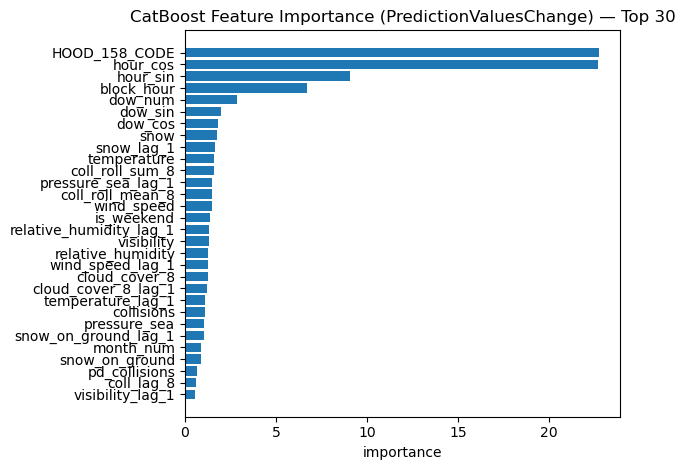

Saved: ../models/feature_importance_catboost_pvc.csv


In [12]:
# Compute CatBoost built-in feature importance
pool_val = Pool(X_val, y_val, cat_features=cat_features_idx)

imp_pvc = cb.get_feature_importance(pool_val, type="PredictionValuesChange")
imp_cb_pvc = pd.DataFrame({"feature": X_val.columns, "importance": imp_pvc}).sort_values("importance", ascending=False)

display(imp_cb_pvc.head(25))

# Plot top 30
top_n = 30
plt.figure()
plt.barh(imp_cb_pvc.head(top_n)["feature"][::-1], imp_cb_pvc.head(top_n)["importance"][::-1])
plt.title("CatBoost Feature Importance (PredictionValuesChange) — Top 30")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

# Save
OUT_PVC = MODEL_DIR / "feature_importance_catboost_pvc.csv"
imp_cb_pvc.to_csv(OUT_PVC, index=False)
print("Saved:", OUT_PVC)


## Permutation importance (Validation)

Permutation importance answers a practical question:

> “If I randomly shuffle this feature on the validation set, how much does performance drop?”

We compute it using:

- **Argmax** decision  
- **Two-threshold** decision (tau1/tau2)

Because this can be slow on huge datasets, we sample validation rows (optional).


In [13]:
# ============================================================
# Permutation importance helper
# ============================================================
def permutation_importance_custom(
    model_name: str,
    predict_proba_fn,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    baseline_metric: float,
    mode: str = "argmax",              # "argmax" or "two_threshold"
    tau1: float | None = None,
    tau2: float | None = None,
    n_repeats: int = 3,
    max_rows: int = 80_000,
    random_seed: int = 42
):
    rng = np.random.default_rng(random_seed)

    # Optional sampling for speed
    if len(X_val) > max_rows:
        idx = rng.choice(len(X_val), size=max_rows, replace=False)
        Xv = X_val.iloc[idx].copy()
        yv = y_val.iloc[idx].copy()
    else:
        Xv = X_val.copy()
        yv = y_val.copy()

    feats = list(Xv.columns)
    scores = []

    for f in feats:
        drops = []
        for r in range(n_repeats):
            Xp = Xv.copy()
            Xp[f] = rng.permutation(Xp[f].values)  # shuffle one column
            proba = predict_proba_fn(Xp)

            if mode == "argmax":
                pred = np.argmax(proba, axis=1)
            elif mode == "two_threshold":
                pred = apply_two_thresholds(proba, tau1=tau1, tau2=tau2)
            else:
                raise ValueError("mode must be 'argmax' or 'two_threshold'")

            macro = recall_score(yv, pred, average="macro", zero_division=0)
            drops.append(baseline_metric - macro)

        scores.append((f, float(np.mean(drops)), float(np.std(drops))))

    out = pd.DataFrame(scores, columns=["feature", "importance_drop", "std_drop"]).sort_values("importance_drop", ascending=False)
    out["model"] = model_name
    out["mode"] = mode
    return out

# Baseline metrics used for drop computation (macro recall on sampled Val)
# We'll recompute baseline on the same sampled rows inside the function by passing baseline_metric from full Val evaluation.
base_metric_cb_argmax = base_cb_argmax["macro_recall"]
base_metric_cb_thr    = base_cb_thr["macro_recall"]

base_metric_lgbm_argmax = base_lgbm_argmax["macro_recall"]
base_metric_lgbm_thr    = base_lgbm_thr["macro_recall"]

print("Baseline macro_recall (CB argmax):", base_metric_cb_argmax)
print("Baseline macro_recall (CB two-thr):", base_metric_cb_thr)


Baseline macro_recall (CB argmax): 0.41601366624433544
Baseline macro_recall (CB two-thr): 0.5450318262029538


In [14]:
# ============================================================
# 6A) Permutation importance — CatBoost
# ============================================================
cb_perm_argmax = permutation_importance_custom(
    model_name="CatBoost",
    predict_proba_fn=lambda X_: cb.predict_proba(X_),
    X_val=X_val, y_val=y_val,
    baseline_metric=base_metric_cb_argmax,
    mode="argmax",
    n_repeats=3,
    max_rows=80_000,
    random_seed=RANDOM_SEED
)

cb_perm_thr = permutation_importance_custom(
    model_name="CatBoost",
    predict_proba_fn=lambda X_: cb.predict_proba(X_),
    X_val=X_val, y_val=y_val,
    baseline_metric=base_metric_cb_thr,
    mode="two_threshold",
    tau1=tau1_cb, tau2=tau2_cb,
    n_repeats=3,
    max_rows=80_000,
    random_seed=RANDOM_SEED
)

display(cb_perm_argmax.head(20))
display(cb_perm_thr.head(20))

# Save
OUT_CB_PERM_ARGMAX = MODEL_DIR / "feature_importance_catboost_perm_argmax.csv"
OUT_CB_PERM_THR = MODEL_DIR / "feature_importance_catboost_perm_two_threshold.csv"
cb_perm_argmax.to_csv(OUT_CB_PERM_ARGMAX, index=False)
cb_perm_thr.to_csv(OUT_CB_PERM_THR, index=False)
print("Saved:", OUT_CB_PERM_ARGMAX)
print("Saved:", OUT_CB_PERM_THR)


,feature,importance_drop,std_drop,model,mode
0,HOOD_158_CODE,0.064288,0.002284,CatBoost,argmax
21,hour_cos,0.037611,0.000964,CatBoost,argmax
20,hour_sin,0.012314,0.001523,CatBoost,argmax
16,block_hour,0.009465,0.000704,CatBoost,argmax
17,dow_num,0.001926,0.000811,CatBoost,argmax
19,is_weekend,0.001614,0.001072,CatBoost,argmax
1,collisions,0.001015,0.000499,CatBoost,argmax
41,snow_lag_1,0.000411,0.000414,CatBoost,argmax
37,coll_roll_sum_8,0.000286,0.000527,CatBoost,argmax
36,coll_roll_mean_8,0.000216,0.000655,CatBoost,argmax


,feature,importance_drop,std_drop,model,mode
0,HOOD_158_CODE,0.126026,0.004928,CatBoost,two_threshold
21,hour_cos,0.087836,0.002901,CatBoost,two_threshold
20,hour_sin,0.027224,0.000557,CatBoost,two_threshold
16,block_hour,0.011025,0.002459,CatBoost,two_threshold
19,is_weekend,0.010344,0.002015,CatBoost,two_threshold
17,dow_num,0.009837,0.001953,CatBoost,two_threshold
36,coll_roll_mean_8,0.009332,0.000708,CatBoost,two_threshold
13,snow,0.008579,0.000597,CatBoost,two_threshold
12,rain,0.008263,0.000231,CatBoost,two_threshold
43,wind_speed_lag_1,0.008209,0.000668,CatBoost,two_threshold


Saved: ../models/feature_importance_catboost_perm_argmax.csv
Saved: ../models/feature_importance_catboost_perm_two_threshold.csv


In [15]:
# --- Speed control for LGBM permutation importance ---
LGBM_MAX_ROWS = 15000
LGBM_REPEATS = 1
LGBM_TOP_N_FEATURES = 40   # only test the most important features
# ============================================================
# 6B) Permutation importance — LightGBM Pipeline
# ============================================================
lgbm_perm_argmax = permutation_importance_custom(
    model_name="LightGBM",
    predict_proba_fn=lambda X_: lgbm_pipe.predict_proba(X_),
    X_val=X_val, y_val=y_val,
    baseline_metric=base_metric_lgbm_argmax,
    mode="argmax",
    n_repeats=3,
    max_rows=80_000,
    random_seed=RANDOM_SEED
)

lgbm_perm_thr = permutation_importance_custom(
    model_name="LightGBM",
    predict_proba_fn=lambda X_: lgbm_pipe.predict_proba(X_),
    X_val=X_val, y_val=y_val,
    baseline_metric=base_metric_lgbm_thr,
    mode="two_threshold",
    tau1=tau1_lg, tau2=tau2_lg,
    n_repeats=3,
    max_rows=80_000,
    random_seed=RANDOM_SEED
)

display(lgbm_perm_argmax.head(20))
display(lgbm_perm_thr.head(20))

OUT_LGBM_PERM_ARGMAX = MODEL_DIR / "feature_importance_lightgbm_perm_argmax.csv"
OUT_LGBM_PERM_THR = MODEL_DIR / "feature_importance_lightgbm_perm_two_threshold.csv"
lgbm_perm_argmax.to_csv(OUT_LGBM_PERM_ARGMAX, index=False)
lgbm_perm_thr.to_csv(OUT_LGBM_PERM_THR, index=False)
print("Saved:", OUT_LGBM_PERM_ARGMAX)
print("Saved:", OUT_LGBM_PERM_THR)


,feature,importance_drop,std_drop,model,mode
0,HOOD_158_CODE,0.081935,0.003535,LightGBM,argmax
21,hour_cos,0.053607,0.003578,LightGBM,argmax
16,block_hour,0.026290,0.000302,LightGBM,argmax
20,hour_sin,0.008393,0.000961,LightGBM,argmax
17,dow_num,0.005984,0.001813,LightGBM,argmax
44,relative_humidity_lag_1,0.003156,0.002132,LightGBM,argmax
38,temperature_lag_1,0.002715,0.001133,LightGBM,argmax
43,wind_speed_lag_1,0.002299,0.000167,LightGBM,argmax
10,temperature,0.002132,0.000209,LightGBM,argmax
45,pressure_sea_lag_1,0.001788,0.001777,LightGBM,argmax


,feature,importance_drop,std_drop,model,mode
0,HOOD_158_CODE,0.085117,0.004631,LightGBM,two_threshold
21,hour_cos,0.063778,0.001011,LightGBM,two_threshold
16,block_hour,0.025665,0.002375,LightGBM,two_threshold
20,hour_sin,0.010359,0.001081,LightGBM,two_threshold
17,dow_num,0.009003,0.001956,LightGBM,two_threshold
37,coll_roll_sum_8,0.005766,0.001464,LightGBM,two_threshold
10,temperature,0.004827,0.000284,LightGBM,two_threshold
46,cloud_cover_8_lag_1,0.004341,0.001181,LightGBM,two_threshold
44,relative_humidity_lag_1,0.004149,0.002455,LightGBM,two_threshold
36,coll_roll_mean_8,0.003674,0.000483,LightGBM,two_threshold


Saved: ../models/feature_importance_lightgbm_perm_argmax.csv
Saved: ../models/feature_importance_lightgbm_perm_two_threshold.csv


## Build a “recommended” feature ranking file

For feature selection, we recommend ranking features by **CatBoost permutation importance (two-threshold)** because it aligns with your final decision policy.

We will save:
- `selected_features_ranked.txt` (top → bottom)
- `selected_features_top25.txt` (top 25)


In [16]:
# Choose a ranking source for feature selection:
rank_source = cb_perm_thr.copy()  # you can switch to cb_perm_argmax if desired

rank_source = rank_source.sort_values(["importance_drop", "std_drop"], ascending=[False, True]).reset_index(drop=True)
ranked_features = rank_source["feature"].tolist()

OUT_RANK = MODEL_DIR / "selected_features_ranked.txt"
with open(OUT_RANK, "w", encoding="utf-8") as f:
    for feat in ranked_features:
        f.write(feat + "\n")
print("Saved:", OUT_RANK)

TOP_K = 25
OUT_TOPK = MODEL_DIR / f"selected_features_top{TOP_K}.txt"
with open(OUT_TOPK, "w", encoding="utf-8") as f:
    for feat in ranked_features[:TOP_K]:
        f.write(feat + "\n")
print("Saved:", OUT_TOPK)

print("Top 20 features:")
print(ranked_features[:20])


Saved: ../models/selected_features_ranked.txt
Saved: ../models/selected_features_top25.txt
Top 20 features:
['HOOD_158_CODE', 'hour_cos', 'hour_sin', 'block_hour', 'is_weekend', 'dow_num', 'coll_roll_mean_8', 'snow', 'rain', 'wind_speed_lag_1', 'coll_lag_2', 'snow_on_ground_lag_1', 'pd_collisions_lag_1', 'coll_roll_sum_4', 'coll_roll_sum_8', 'ftr_collisions_lag_1', 'visibility', 'snow_on_ground', 'coll_lag_1', 'injury_collisions_lag_1']
